# Prétraitement des données (Data Processing)

**Plan du notebook :**
1. Téléchargement et chargement du dataset
2. Exploration visuelle des données (Images et points clés)
3. Nettoyage et formatage des labels (Optimisation avec `dataset.map()`)
4. Analyse de la distribution des chiffres par grille et Baseline
5. Découpage et redressement des vignettes

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset

In [20]:
# Téléchargement et mise en cache automatique du dataset complet
dataset = load_dataset("Lexski/sudoku-image-recognition")

print("Aperçu du dataset :")
print(dataset)

Aperçu du dataset :
DatasetDict({
    train: Dataset({
        features: ['image', 'cells', 'keypoints'],
        num_rows: 1000
    })
    validation: Dataset({
        features: ['image', 'cells', 'keypoints'],
        num_rows: 200
    })
    test: Dataset({
        features: ['image', 'cells', 'keypoints'],
        num_rows: 200
    })
})


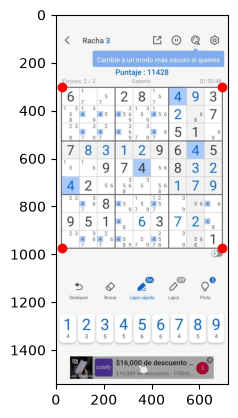

Dimensions de l'image : (1544, 720, 3)
Application du prétraitement sur tout le dataset...

Vérification grille 931 (doit être vide) :
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]

Vérification grille 20 :
[6 0 0 2 8 0 4 9 3]


In [21]:
# Affichage d'une image de grille de Sudoku
idx_exemple = 20
image_ex = np.array(dataset['train'][idx_exemple]['image'])
keypoints_ex = dataset['train'][idx_exemple]['keypoints']

# Visualisation des coins d'une grille
x_cords = keypoints_ex[0::2]
y_cords = keypoints_ex[1::2]

plt.imshow(image_ex)
plt.scatter(x_cords, y_cords, c='r')
plt.show()

print(f"Dimensions de l'image : {image_ex.shape}")

def pretraitement_labels(exemple):
    cells_array = np.array(exemple['cells'])
    
    # On crée un masque 
    mask_resolu = cells_array[:, :, 0] != 0
    
    # On trouve le chiffre (de 1 à 9) en cherchant le maximum uniquement dans les index 1 à 9
    chiffres = np.argmax(cells_array[:, :, 1:], axis=-1) + 1
    
    new_cells = np.where(mask_resolu, chiffres, 0)
    
    return {"cells_clean": new_cells.tolist()}

print("Application du prétraitement sur tout le dataset...")
dataset_clean = dataset.map(pretraitement_labels)

# Vérification (la grille 931 doit n'avoir que des 0, la grille 20 doit commencer par 6, 0, 0, 2...)
print("\nVérification grille 931 (doit être vide) :")
print(np.array(dataset_clean['train'][931]['cells_clean']))
print("\nVérification grille 20 :")
print(np.array(dataset_clean['train'][20]['cells_clean'])[0]) # Première ligne

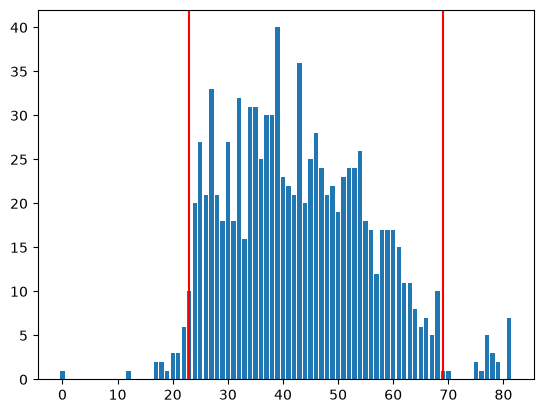

Nombre de grilles < 23 chiffres est : 19
23 <= Nombre de grilles < 46 est : 577
46 <= Nombre de grilles < 69 est : 382
Nombre de grilles >= 69 est : 22

Nous constatons qu'il y a 3 zones, 2 minoritaires et 1 majoritaire.
Nous allons utiliser ces 3 tranches pour tester notre modèle!


In [22]:
# Affiche et Explore le nombre de chiffres par grille pour les grilles d'entraînement
toutes_les_grilles = np.array(dataset_clean['train']['cells_clean'])

# On compte les chiffres != 0 par grille
n_ch_grille = np.count_nonzero(toutes_les_grilles, axis=(1, 2))

nombre, occurence = np.unique(n_ch_grille, return_counts=True)

plt.bar(nombre, occurence)
plt.axvline(x=23, color='r')
plt.axvline(x=69, color='r')
plt.show()

print(f"Nombre de grilles < 23 chiffres est : {np.sum(n_ch_grille < 23)}")
print(f"23 <= Nombre de grilles < 46 est : {np.sum((n_ch_grille >= 23) & (n_ch_grille < 46))}")
print(f"46 <= Nombre de grilles < 69 est : {np.sum((n_ch_grille >= 46) & (n_ch_grille < 69))}")
print(f"Nombre de grilles >= 69 est : {np.sum(n_ch_grille >= 69)}")
print("\nNous constatons qu'il y a 3 zones, 2 minoritaires et 1 majoritaire.")
print("Nous allons utiliser ces 3 tranches pour tester notre modèle!")

Recherche des grilles vides...
La grille à l'index 931 contient 0 chiffres.

Affichage de la grille 931 :


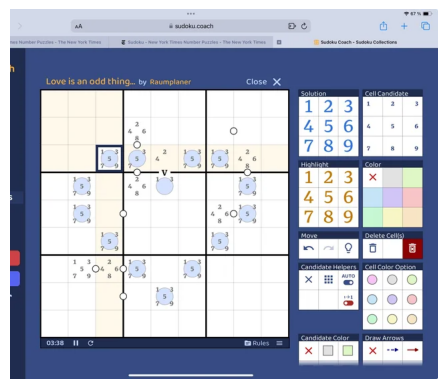

Matrice des labels pour la grille 931 :
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [23]:
# Grille contenant 0 chiffres
print("Recherche des grilles vides...")
for i in range(1000):
    if np.count_nonzero(toutes_les_grilles[i]) == 0:
        print(f"La grille à l'index {i} contient 0 chiffres.")

print("\nAffichage de la grille 931 :")
plt.imshow(dataset['train'][931]['image'])
plt.axis('off')
plt.show()

print("Matrice des labels pour la grille 931 :")
print(toutes_les_grilles[931])

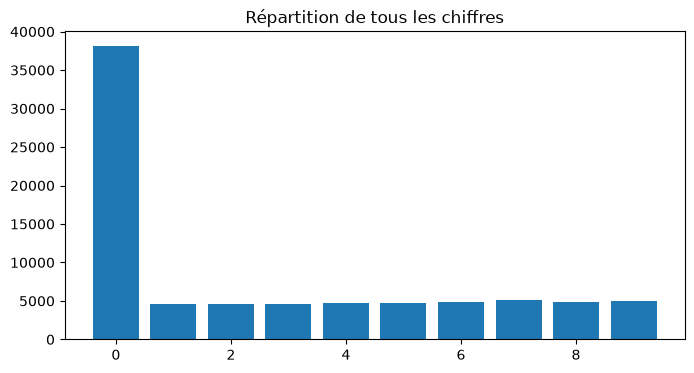

On observe une forte répartition pour les cases vides (0), Environ un x8
Ça veut dire qu'un modèle stupide qui prédirait vide (0) à chaque fois aurait une exactitude de 0.471
C'est notre Baseline, il faut faire mieux !


In [24]:
# Calcul l'occurrence de chaque chiffre dans les grilles d'entraînement
tous_les_chiffres = toutes_les_grilles.flatten()

nombre, occurence_chiffre = np.unique(tous_les_chiffres, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(nombre, occurence_chiffre)
plt.title("Répartition de tous les chiffres")
plt.show()

print("On observe une forte répartition pour les cases vides (0), Environ un x8")
exactitude = occurence_chiffre[0] / len(tous_les_chiffres)
print(f"Ça veut dire qu'un modèle stupide qui prédirait vide (0) à chaque fois aurait une exactitude de {exactitude:.3f}")
print("C'est notre Baseline, il faut faire mieux !")

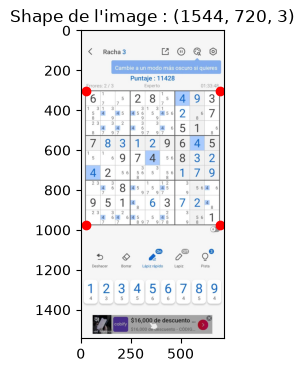

Redressement et découpage de toutes les grilles...


Map: 100%|██████████| 200/200 [00:03<00:00, 52.72 examples/s]


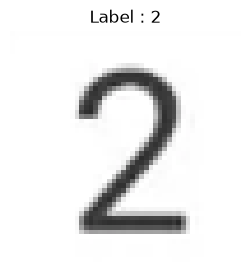

In [27]:
import cv2
from PIL import Image

# Vérification de l'image et des points clés
img = np.array(dataset['train'][20]['image'])
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.scatter(keypoints_ex[0::2], keypoints_ex[1::2], c='r')
plt.title(f"Shape de l'image : {img.shape}")
plt.show()

# Définition de la fonction de redressement et découpage
def crop_grille(exemple, size=450):
    img = np.array(exemple['image'])

    # Récupération des coins
    trapeze = np.array(exemple['keypoints'], dtype=np.float32).reshape(4, 2)
    carre = np.array([
        [0, 0],
        [0, size],
        [size, size],
        [size, 0]
    ], dtype=np.float32)
    
    # Transformation de l'image (redressement)
    matrice = cv2.getPerspectiveTransform(trapeze, carre)
    new_image = cv2.warpPerspective(img, matrice, (size, size))

    vignettes_pil = []
    marge = 5
    pas = size // 9
    
    for i in range(0, size, pas):
        for j in range(0, size, pas):
            # Ajout de la marge pour éviter les lignes noires
            vignette = new_image[i + marge : i + pas - marge, j + marge : j + pas - marge]
            vignette_pil = Image.fromarray(vignette).resize((pas, pas))
            vignettes_pil.append(vignette_pil)

    
    # on l'aplatit en une liste de 81 éléments
    etiquettes = np.array(exemple['cells_clean']).flatten().tolist()
    
    return {
        'vignettes_pil': vignettes_pil,
        'etiquettes': etiquettes
    }

print("Redressement et découpage de toutes les grilles...")
# On applique la fonction sur dataset_clean (qui contient train, validation, test)
dataset_crop = dataset_clean.map(crop_grille, writer_batch_size=50)


plt.figure(figsize=(3, 3))
plt.imshow(dataset_crop['train']['vignettes_pil'][20][3])
plt.title(f"Label : {dataset_crop['train']['etiquettes'][20][3]}")
plt.axis('off')
plt.show()

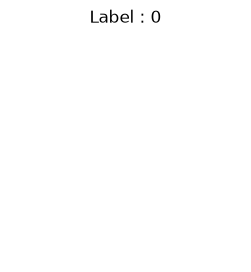


Reconstitution visuelle de la grille 931 :


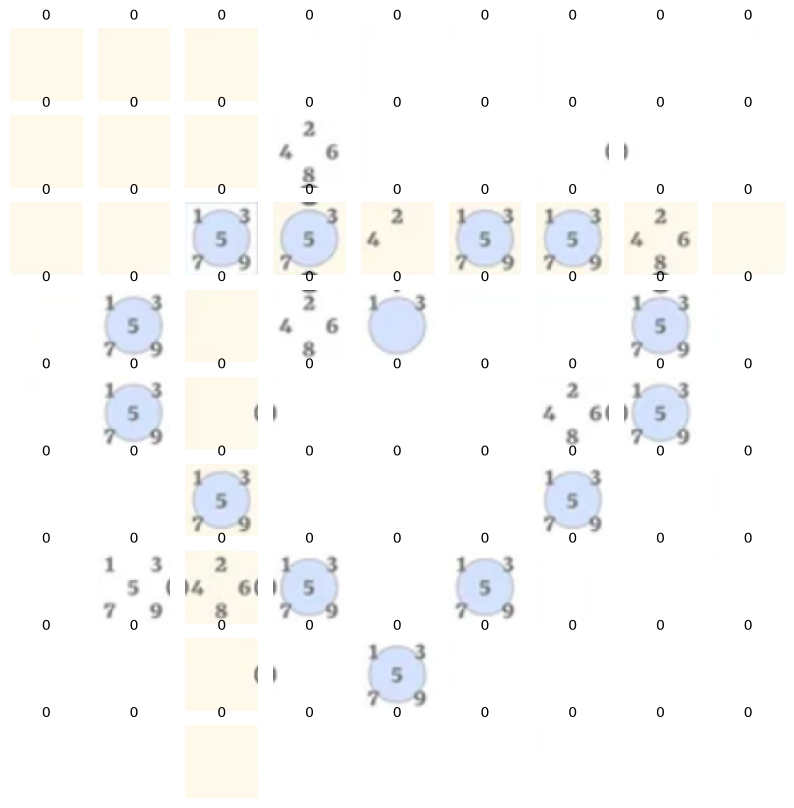

In [28]:
# Affichage d'une autre vignette isolée
plt.figure(figsize=(3, 3))
plt.imshow(dataset_crop['train']['vignettes_pil'][137][2])
plt.title(f"Label : {dataset_crop['train']['etiquettes'][137][2]}")
plt.axis('off')
plt.show()

# Affichage des 81 cases de la grille 931
print("\nReconstitution visuelle de la grille 931 :")
fig, axes = plt.subplots(9, 9, figsize=(10, 10))

for n in range(81):
    i = n // 9
    j = n % 9
    
    vignette = dataset_crop['train']["vignettes_pil"][931][n]
    label = dataset_crop['train']["etiquettes"][931][n]
    
    axes[i, j].imshow(vignette)
    axes[i, j].set_title(str(label), fontsize=10)
    axes[i, j].axis('off')

plt.show()